# 手書き数字認識 - 学習アルゴリズム改善版

このノートブックは `1_handwriting_recognition_model_architecture.ipynb` の学習アルゴリズムのみを改善したバージョンです。

## 変更点：
- ✅ SGD → AdamW オプティマイザ
- ✅ 学習率スケジューラ (CosineAnnealingLR) の追加
- ✅ Gradient Clipping の追加

## 変更しない部分：
- モデルアーキテクチャ (ModernCNN)
- データセット処理
- 前処理・正規化

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

import random
import cv2
import sys
import gc
import os
import time
import warnings

from sklearn.metrics import accuracy_score, confusion_matrix

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.autograd import Variable, detect_anomaly
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid

from PIL import Image, ImageOps, ImageEnhance

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
# train_size = len(os.listdir("train/"))
# test_size = len(os.listdir("test/"))
train_size = len(os.listdir("../data/train/"))
test_size = len(os.listdir("../data/test/"))
print(f"学習データの枚数: {train_size}")
print(f"テストデータの枚数: {test_size}")

学習データの枚数: 60000
テストデータの枚数: 10000


In [49]:
seeds = 777
torch.manual_seed(seeds)
random.seed(seeds)
np.random.seed(seeds)
torch.cuda.manual_seed(seeds)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

# 適当な画像を確認

In [50]:
image = Image.open(os.path.join('../data/train', 'train_0.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


In [51]:
image = Image.open(os.path.join('../data/train', 'train_12.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


In [52]:
image = Image.open(os.path.join('../data/test', 'test_0.jpg'))
print('width, height:', image.size)
image

width, height: (28, 28)


それぞれ画像の大きさは横×縦が28×28で, グレースケール画像であることが確認できました.

学習用画像データにおけるそれぞれの数字の分布をみてみます.

In [53]:
train_master = pd.read_csv("../assets/train_master.csv")
train_master.head()

,file_name,category_id
0,train_0.jpg,5
1,train_1.jpg,0
2,train_2.jpg,4
3,train_3.jpg,1
4,train_4.jpg,9


In [54]:
train_master['category_id'].value_counts().sort_index()

category_id
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64

# 手法
次に実際にモデリングを行い, 評価用画像データに対して予測をできるようにします.
今回は7層の比較的浅い畳み込みニューラルネットワークモデル(LeNet[1])によりモデリングを試みます.

実装はpytorchを用います.

まず60,000枚の学習用画像データを読み込みます. その際, あらかじめデータの数値の範囲が[0, 1]となるように正規化しておきます.

pytorchではモデルに学習データを渡す際は(サンプル数, チャンネル数, 縦, 横)の形でなければならないので, そのように変形しておきます.

# DataLoader

In [55]:
class MNIST_data(Dataset):
    """MNIST dtaa set"""

    def __init__(self, data, mode, transform=None):

        self.df = data
        self.tsfm = transform
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name, label = self.df.loc[idx, "file_name"], self.df.loc[idx, "category_id"]
        if self.mode == "train":
            image = cv2.imread(f"../data/{self.mode}/{image_name}", cv2.IMREAD_GRAYSCALE)
            label = torch.tensor(label)
            if self.tsfm != None:
                image = self.tsfm(image.astype(dtype=np.uint8))
            else:
                image = torch.FloatTensor(image)

        else:
            image = cv2.imread(f"../data/{self.mode}/{image_name}", cv2.IMREAD_GRAYSCALE)
            label = torch.tensor(label)
            if self.tsfm != None:
                image = self.tsfm(image.astype(dtype=np.uint8))
            else:
                image = torch.FloatTensor(image)

        return image, label

In [56]:
transform_train = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize([0.5], [0.5])])
transform_test = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize([0.5], [0.5])])

In [57]:
sample = MNIST_data(train_master, mode="train", transform=transform_train)
sample_loader = torch.utils.data.DataLoader(dataset=sample, batch_size=16, shuffle=True, worker_init_fn=seeds)

確認

In [58]:
images, labels = next(iter(sample_loader))

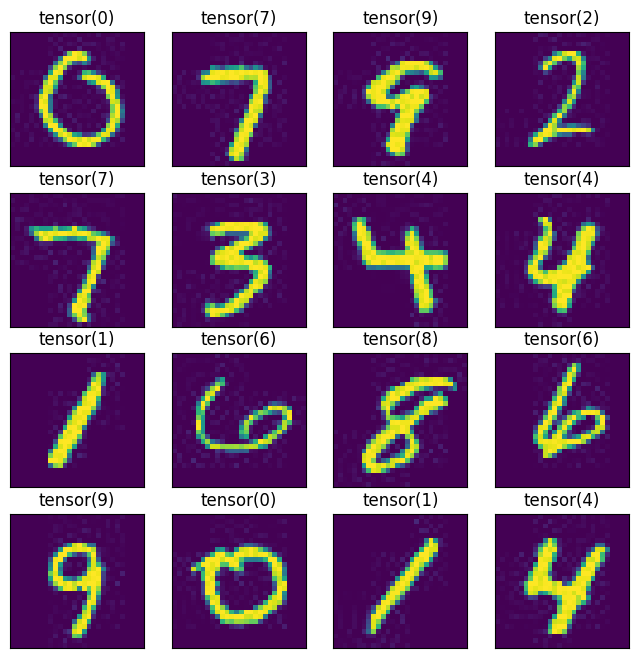

In [59]:
plt.figure(figsize=(8,8))
for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4,i+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(label)
    plt.xticks(())
    plt.yticks(())
plt.show()

# Model作成&損失関数設定

In [60]:
class LeNet(nn.Module):
    def __init__(self, output_size=10, activation='relu'):
        super(LeNet, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, output_size)

        # 活性化関数の辞書
        self.activations = {
            'relu': F.relu,
            'sigmoid': torch.sigmoid,
            'tanh': torch.tanh
        }

    def forward(self, x):
        act_func = self.activations.get(self.activation, F.relu)
        x = self.pool(act_func(self.conv1(x)))
        x = self.pool(act_func(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = act_func(self.fc1(x))
        x = act_func(self.fc2(x))
        x = self.fc3(x)
        return x

In [61]:
class ModernCNN(nn.Module):
    def __init__(self, output_size=10):
        super(ModernCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        # Dropoutを削除または大幅に削減
        # self.dropout = nn.Dropout(0.25)  # 削除
        self.dropout = nn.Dropout(0.1)  # または0.1に削減
        
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, output_size)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        # x = self.dropout(x)  # 削除
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        # x = self.dropout(x)  # 削除
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        # 全結合層の前だけに軽いDropoutを適用
        x = self.dropout(x)  # ここだけ残す（0.1-0.2程度）
        
        x = self.fc(x)
        return x

In [62]:
# 使用するモデルを選択（変更なし）
# model = LeNet(output_size=10, activation='tanh')
model = ModernCNN(output_size=10)

# 【改善】オプティマイザをAdamWに変更
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 元のSGD
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)  # AdamWに変更

# 【改善】学習率スケジューラの追加
EPOCH = 30  # エポック数を増やす（Early Stoppingがあるので問題なし）
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCH, eta_min=1e-6)

# 損失関数（変更なし）
criterion = nn.CrossEntropyLoss()

In [63]:
# モデルのパラメータ数を計算する関数（変更なし）
def count_parameters(model):
    """モデルの総パラメータ数と訓練可能なパラメータ数を計算"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def print_model_summary(model, model_name):
    """モデルのサマリーを表示"""
    total, trainable = count_parameters(model)
    print(f"\n{'='*60}")
    print(f"{model_name} のパラメータ数")
    print(f"{'='*60}")
    print(f"総パラメータ数:       {total:,}")
    print(f"訓練可能パラメータ数: {trainable:,}")
    print(f"{'='*60}\n")
    return total, trainable

# モデルサマリー表示
print_model_summary(model, "ModernCNN")


ModernCNN のパラメータ数
総パラメータ数:       56,714
訓練可能パラメータ数: 56,714



(56714, 56714)

# 訓練

In [64]:
#GPUを使うか使わないか(使う場合cudaになり、使わない場合cpuとなる)
device = ""

if torch.cuda.is_available():
    device = "cuda"

if torch.backends.mps.is_available():
    device = "mps"

if device == "":
    device = "cpu"
    
print(f"Using device: {device}")

Using device: mps


In [65]:
model = model.to(device)

In [66]:
train, valid, _, _ = train_test_split(train_master, train_master["category_id"], test_size=0.25, random_state=seeds)
train = train.reset_index(drop=True)
valid = valid.reset_index(drop=True)

In [67]:
batch_size = 64
train_data = MNIST_data(train, mode="train", transform=transform_train)
valid_data = MNIST_data(valid, mode="train", transform=transform_test)
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, worker_init_fn=seeds)
valid_loader = torch.utils.data.DataLoader(dataset=valid_data, batch_size=batch_size)

In [68]:
# EPOCH = 10  # 上で30に変更済み
total_batch = int(len(train_loader)/12)

In [69]:
# 【改善】Early Stoppingクラスの追加
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf  # np.Inf -> np.inf に修正（NumPy 2.0対応）
        self.delta = delta
        self.best_model = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.best_model = model.state_dict().copy()
        self.val_loss_min = val_loss

In [70]:
# 【改善】学習関数を更新（Gradient Clipping、学習率スケジューラ、Early Stopping対応）
def training_validation(input_model, EPOCH, training_data, validation_data, num_update):
    total_batch = int(len(training_data)/num_update)
    
    # 履歴を記録するリスト
    history = {
        'train_loss': [],
        'valid_loss': [],
        'valid_accuracy': [],
        'learning_rate': []  # 学習率の履歴も記録
    }
    
    # Early Stoppingの初期化
    early_stopping = EarlyStopping(patience=7, verbose=True)
    
    for epoch in range(1, EPOCH+1):
        input_model.train()
        #訓練プロセス
        train_loss = []
        pbar = tqdm.tqdm(enumerate(training_data), total = len(training_data))
        for process, (images, labels) in pbar:
            images = images.to(device)
            labels = labels.to(device)
            time_1 = time.time()
            outputs = input_model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            
            # 【改善】Gradient Clippingの追加
            torch.nn.utils.clip_grad_norm_(input_model.parameters(), max_norm=1.0)
            
            optimizer.step()
            loss = loss.item()
            train_loss.append(loss)
            if (process % total_batch == 0) | (process == len(training_data)):
                pbar.set_postfix(EPOCH=epoch, train_loss=np.mean(train_loss), lr=optimizer.param_groups[0]['lr'])

        #検証プロセス
        input_model.eval()
        valid_loss = []
        correct = 0
        valid_time = time.time()
        for process, (images, labels) in enumerate(validation_data):
            images = images.to(device)
            labels = labels.to(device)
            outputs = input_model(images)
            loss = criterion(outputs, labels)
            loss = loss.item()
            valid_loss.append(loss)
            pred = outputs.data.max(1, keepdim=True)[1]
            correct += pred.eq(labels.data.view_as(pred)).cpu().sum().item()
        minute, second = int((time.time()-valid_time)//59), int((time.time()-valid_time)%60)
        
        # エポックごとの結果を記録
        epoch_train_loss = np.mean(train_loss)
        epoch_valid_loss = np.mean(valid_loss)
        epoch_valid_accuracy = correct/len(validation_data.dataset)
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(epoch_train_loss)
        history['valid_loss'].append(epoch_valid_loss)
        history['valid_accuracy'].append(epoch_valid_accuracy)
        history['learning_rate'].append(current_lr)
        
        pbar.set_postfix(EPOCH=epoch, train_loss=epoch_train_loss, valid_loss=epoch_valid_loss, valid_accuracy=epoch_valid_accuracy)
        print(f"Epoch {epoch}: valid_loss: {epoch_valid_loss:.4f}, valid_accuracy: {epoch_valid_accuracy:.4f}, lr: {current_lr:.6f}")
        
        # 【改善】学習率スケジューラのステップ
        scheduler.step()
        
        # 【改善】Early Stopping
        early_stopping(epoch_valid_loss, input_model)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch}")
            # 最良モデルをロード
            input_model.load_state_dict(early_stopping.best_model)
            break

    # 最良モデルをロード（early stoppingしなかった場合も）
    if early_stopping.best_model is not None:
        input_model.load_state_dict(early_stopping.best_model)
        print(f"Best model loaded with validation loss: {early_stopping.val_loss_min:.6f}")
    
    return_model = input_model

    return return_model, history

In [71]:
# 予測結果のそれぞれの誤差の大きさを確認（変更なし）
def predict_img(input_model, input_data):
    input_model.eval()
    test_pred = torch.LongTensor()
    test_proba = torch.FloatTensor()
    for images, labels in tqdm.tqdm(input_data):
        images = images.to(device)
        labels = labels.to(device)
        outputs = input_model(images)
        pred_proba = F.softmax(outputs, dim=1).cpu()
        pred = outputs.data.max(1, keepdim=True)[1].view(-1)
        pred = torch.stack([labels,pred],axis=1).cpu()
        test_pred = torch.cat((test_pred, pred), dim=0)
        test_proba = torch.cat((test_proba, pred_proba), dim=0)
    test_pred = test_pred.cpu().detach().numpy()
    test_proba = test_proba.cpu().detach().numpy()
    loss_correct = np.array(pd.get_dummies(test_pred[:,0]))
    test_loss = -(loss_correct*np.log(test_proba+1e-07)).sum(axis=1)
    test_pred = pd.DataFrame(test_pred).rename(columns = {0:"label" ,1:"predict"})
    test_proba = pd.DataFrame(test_proba).rename(columns = {0:"proba_0", 1:"proba_1", 2:"proba_2", 3:"proba_3", 4:"proba_4",
                                                            5:"proba_5", 6:"proba_6", 7:"proba_7", 8:"proba_8", 9:"proba_9"})
    test_loss = pd.DataFrame(test_loss).rename(columns = {0:"loss"})
    df = pd.concat([test_pred, test_proba, test_loss], axis=1)
    del loss_correct
    gc.collect()
    return df

ModernCNNモデルを学習させてみます.

In [72]:
model, history = training_validation(model, EPOCH, train_loader, valid_loader, 12)

100%|██████████| 704/704 [02:38<00:00,  4.45it/s, EPOCH=1, lr=0.001, train_loss=0.526]


Epoch 1: valid_loss: 0.2243, valid_accuracy: 0.9397, lr: 0.001000
Validation loss decreased (inf --> 0.224284).  Saving model ...


100%|██████████| 704/704 [31:34<00:00,  2.69s/it, EPOCH=2, lr=0.000997, train_loss=0.128]    


Epoch 2: valid_loss: 0.1325, valid_accuracy: 0.9643, lr: 0.000997
Validation loss decreased (0.224284 --> 0.132512).  Saving model ...


100%|██████████| 704/704 [16:23<00:00,  1.40s/it, EPOCH=3, lr=0.000989, train_loss=0.0883]    


Epoch 3: valid_loss: 0.1771, valid_accuracy: 0.9459, lr: 0.000989
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [16:23<00:00,  1.40s/it, EPOCH=4, lr=0.000976, train_loss=0.0728]    


Epoch 4: valid_loss: 0.1634, valid_accuracy: 0.9494, lr: 0.000976
EarlyStopping counter: 2 out of 7


100%|██████████| 704/704 [09:54<00:00,  1.19it/s, EPOCH=5, lr=0.000957, train_loss=0.0587] 


Epoch 5: valid_loss: 0.0817, valid_accuracy: 0.9766, lr: 0.000957
Validation loss decreased (0.132512 --> 0.081746).  Saving model ...


100%|██████████| 704/704 [31:24<00:00,  2.68s/it, EPOCH=6, lr=0.000933, train_loss=0.0502]    


Epoch 6: valid_loss: 0.0730, valid_accuracy: 0.9766, lr: 0.000933
Validation loss decreased (0.081746 --> 0.073008).  Saving model ...


100%|██████████| 704/704 [31:37<00:00,  2.70s/it, EPOCH=7, lr=0.000905, train_loss=0.0444]   


Epoch 7: valid_loss: 0.0707, valid_accuracy: 0.9777, lr: 0.000905
Validation loss decreased (0.073008 --> 0.070713).  Saving model ...


100%|██████████| 704/704 [01:34<00:00,  7.48it/s, EPOCH=8, lr=0.000872, train_loss=0.0408]


Epoch 8: valid_loss: 0.0598, valid_accuracy: 0.9824, lr: 0.000872
Validation loss decreased (0.070713 --> 0.059751).  Saving model ...


100%|██████████| 704/704 [31:37<00:00,  2.70s/it, EPOCH=9, lr=0.000835, train_loss=0.0346]    


Epoch 9: valid_loss: 0.0729, valid_accuracy: 0.9779, lr: 0.000835
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [31:14<00:00,  2.66s/it, EPOCH=10, lr=0.000794, train_loss=0.0311]    


Epoch 10: valid_loss: 0.0495, valid_accuracy: 0.9849, lr: 0.000794
Validation loss decreased (0.059751 --> 0.049477).  Saving model ...


100%|██████████| 704/704 [31:40<00:00,  2.70s/it, EPOCH=11, lr=0.00075, train_loss=0.0285]    


Epoch 11: valid_loss: 0.0489, valid_accuracy: 0.9853, lr: 0.000750
Validation loss decreased (0.049477 --> 0.048929).  Saving model ...


100%|██████████| 704/704 [16:33<00:00,  1.41s/it, EPOCH=12, lr=0.000704, train_loss=0.026]    


Epoch 12: valid_loss: 0.0654, valid_accuracy: 0.9805, lr: 0.000704
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [27:31<00:00,  2.35s/it, EPOCH=13, lr=0.000655, train_loss=0.0226]    


Epoch 13: valid_loss: 0.0683, valid_accuracy: 0.9806, lr: 0.000655
EarlyStopping counter: 2 out of 7


100%|██████████| 704/704 [31:27<00:00,  2.68s/it, EPOCH=14, lr=0.000604, train_loss=0.02]      


Epoch 14: valid_loss: 0.0430, valid_accuracy: 0.9867, lr: 0.000604
Validation loss decreased (0.048929 --> 0.043004).  Saving model ...


100%|██████████| 704/704 [16:32<00:00,  1.41s/it, EPOCH=15, lr=0.000553, train_loss=0.017]     


Epoch 15: valid_loss: 0.0426, valid_accuracy: 0.9870, lr: 0.000553
Validation loss decreased (0.043004 --> 0.042552).  Saving model ...


100%|██████████| 704/704 [01:19<00:00,  8.90it/s, EPOCH=16, lr=0.000501, train_loss=0.0154]


Epoch 16: valid_loss: 0.0428, valid_accuracy: 0.9875, lr: 0.000501
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [01:26<00:00,  8.13it/s, EPOCH=17, lr=0.000448, train_loss=0.0134]


Epoch 17: valid_loss: 0.0424, valid_accuracy: 0.9869, lr: 0.000448
Validation loss decreased (0.042552 --> 0.042390).  Saving model ...


100%|██████████| 704/704 [01:25<00:00,  8.28it/s, EPOCH=18, lr=0.000397, train_loss=0.0123] 


Epoch 18: valid_loss: 0.0444, valid_accuracy: 0.9872, lr: 0.000397
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [01:45<00:00,  6.66it/s, EPOCH=19, lr=0.000346, train_loss=0.0111] 


Epoch 19: valid_loss: 0.0457, valid_accuracy: 0.9873, lr: 0.000346
EarlyStopping counter: 2 out of 7


100%|██████████| 704/704 [00:13<00:00, 51.24it/s, EPOCH=20, lr=0.000297, train_loss=0.0103] 


Epoch 20: valid_loss: 0.0408, valid_accuracy: 0.9881, lr: 0.000297
Validation loss decreased (0.042390 --> 0.040830).  Saving model ...


100%|██████████| 704/704 [00:45<00:00, 15.33it/s, EPOCH=21, lr=0.000251, train_loss=0.00817]


Epoch 21: valid_loss: 0.0405, valid_accuracy: 0.9878, lr: 0.000251
Validation loss decreased (0.040830 --> 0.040491).  Saving model ...


100%|██████████| 704/704 [01:00<00:00, 11.58it/s, EPOCH=22, lr=0.000207, train_loss=0.00752]


Epoch 22: valid_loss: 0.0389, valid_accuracy: 0.9889, lr: 0.000207
Validation loss decreased (0.040491 --> 0.038948).  Saving model ...


100%|██████████| 704/704 [01:49<00:00,  6.41it/s, EPOCH=23, lr=0.000166, train_loss=0.00646]


Epoch 23: valid_loss: 0.0393, valid_accuracy: 0.9897, lr: 0.000166
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [01:32<00:00,  7.64it/s, EPOCH=24, lr=0.000129, train_loss=0.00584]


Epoch 24: valid_loss: 0.0379, valid_accuracy: 0.9890, lr: 0.000129
Validation loss decreased (0.038948 --> 0.037940).  Saving model ...


100%|██████████| 704/704 [01:48<00:00,  6.48it/s, EPOCH=25, lr=9.64e-5, train_loss=0.00619]


Epoch 25: valid_loss: 0.0374, valid_accuracy: 0.9893, lr: 0.000096
Validation loss decreased (0.037940 --> 0.037400).  Saving model ...


100%|██████████| 704/704 [01:49<00:00,  6.40it/s, EPOCH=26, lr=6.79e-5, train_loss=0.00536]


Epoch 26: valid_loss: 0.0378, valid_accuracy: 0.9888, lr: 0.000068
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [00:13<00:00, 51.41it/s, EPOCH=27, lr=4.42e-5, train_loss=0.00517]


Epoch 27: valid_loss: 0.0370, valid_accuracy: 0.9890, lr: 0.000044
Validation loss decreased (0.037400 --> 0.036995).  Saving model ...


100%|██████████| 704/704 [00:13<00:00, 52.09it/s, EPOCH=28, lr=2.54e-5, train_loss=0.00511]


Epoch 28: valid_loss: 0.0372, valid_accuracy: 0.9890, lr: 0.000025
EarlyStopping counter: 1 out of 7


100%|██████████| 704/704 [00:13<00:00, 50.79it/s, EPOCH=29, lr=1.19e-5, train_loss=0.00464]


Epoch 29: valid_loss: 0.0377, valid_accuracy: 0.9890, lr: 0.000012
EarlyStopping counter: 2 out of 7


100%|██████████| 704/704 [00:13<00:00, 51.23it/s, EPOCH=30, lr=3.74e-6, train_loss=0.0048] 


Epoch 30: valid_loss: 0.0376, valid_accuracy: 0.9891, lr: 0.000004
EarlyStopping counter: 3 out of 7
Best model loaded with validation loss: 0.036995


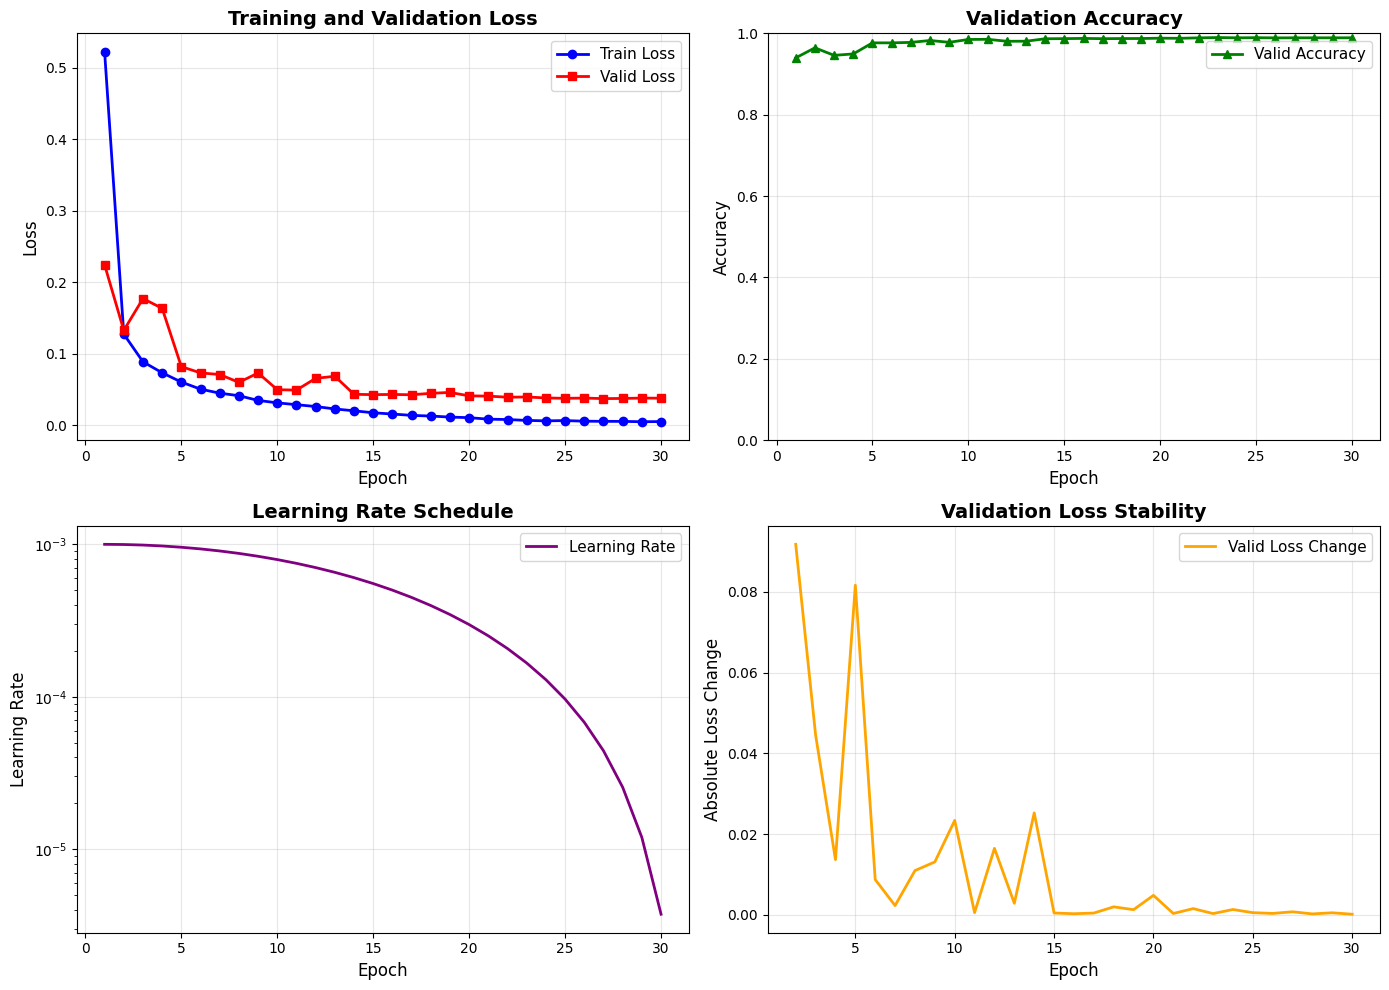


=== 学習結果サマリー ===
最終訓練損失: 0.0049
最終検証損失: 0.0376
最終検証精度: 0.9891
最良検証精度: 0.9897 (Epoch 23)

=== 安定性メトリクス ===
検証損失の標準偏差（後半5エポック）: 0.0003
検証精度の標準偏差（後半5エポック）: 0.0001


In [73]:
# 【改善】学習過程の可視化を改良（学習率の推移も表示）
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 損失の推移
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(epochs, history['valid_loss'], 'r-s', label='Valid Loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 精度の推移
ax2.plot(epochs, history['valid_accuracy'], 'g-^', label='Valid Accuracy', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# 学習率の推移（新規追加）
ax3.plot(epochs, history['learning_rate'], 'purple', label='Learning Rate', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Learning Rate', fontsize=12)
ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

# 損失の変化率（安定性の指標）
if len(history['valid_loss']) > 1:
    loss_changes = [abs(history['valid_loss'][i] - history['valid_loss'][i-1]) 
                    for i in range(1, len(history['valid_loss']))]
    ax4.plot(epochs[1:], loss_changes, 'orange', label='Valid Loss Change', linewidth=2)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.set_ylabel('Absolute Loss Change', fontsize=12)
    ax4.set_title('Validation Loss Stability', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 最終結果の表示
print("\n=== 学習結果サマリー ===")
print(f"最終訓練損失: {history['train_loss'][-1]:.4f}")
print(f"最終検証損失: {history['valid_loss'][-1]:.4f}")
print(f"最終検証精度: {history['valid_accuracy'][-1]:.4f}")
print(f"最良検証精度: {max(history['valid_accuracy']):.4f} (Epoch {history['valid_accuracy'].index(max(history['valid_accuracy'])) + 1})")
print(f"\n=== 安定性メトリクス ===")
print(f"検証損失の標準偏差（後半5エポック）: {np.std(history['valid_loss'][-5:]):.4f}")
print(f"検証精度の標準偏差（後半5エポック）: {np.std(history['valid_accuracy'][-5:]):.4f}")

学習済みモデルの予測結果を確認

In [74]:
predict_df = predict_img(model, valid_loader)

100%|██████████| 235/235 [00:04<00:00, 57.43it/s]


混合行列でModernCNNのそれぞれの数字の精度を確認

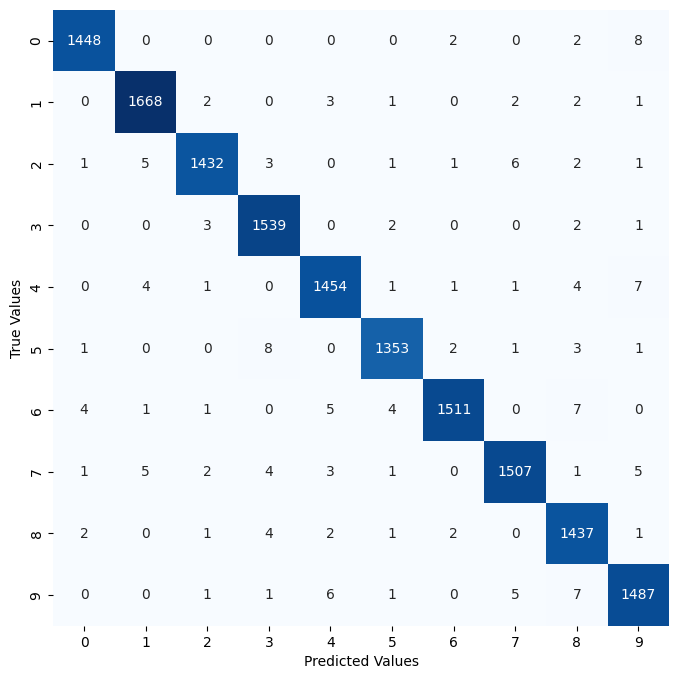

In [75]:
plt.figure(figsize=(8,8))
mat = confusion_matrix(predict_df["label"], predict_df["predict"]) # Confusion matrix
# Plot Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=False, cmap=plt.cm.Blues, fmt="d")
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

間違えた予測の一覧を確認します

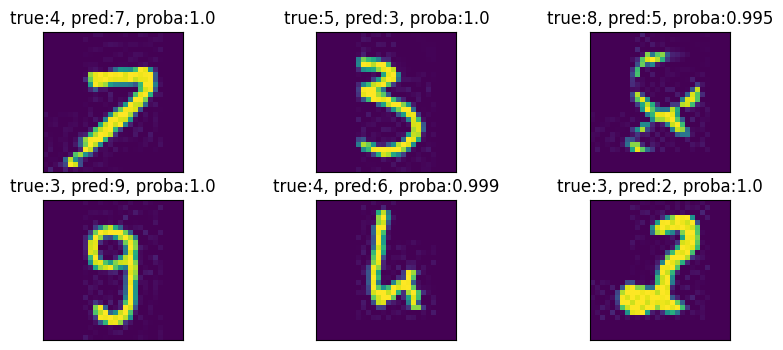

In [76]:
# 大きく間違えた予測
error_index = predict_df[predict_df["label"] != predict_df["predict"]].sort_values(by="loss",ascending=False).head(6).index
plt.figure(figsize=(10,4))
for i, ind in enumerate(error_index):
    label = int(predict_df.iloc[ind]["label"])
    pred = int(predict_df.iloc[ind]["predict"])
    proba = predict_df.iloc[ind]["proba_"+str(pred)]

    image_name = valid.reset_index(drop=True).loc[ind, "file_name"]
    image = cv2.imread(f"../data/train/{image_name}", cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title("true:{}, pred:{}, proba:{}".format(label, pred, proba.round(3)))
    plt.xticks(())
    plt.yticks(())
plt.show()

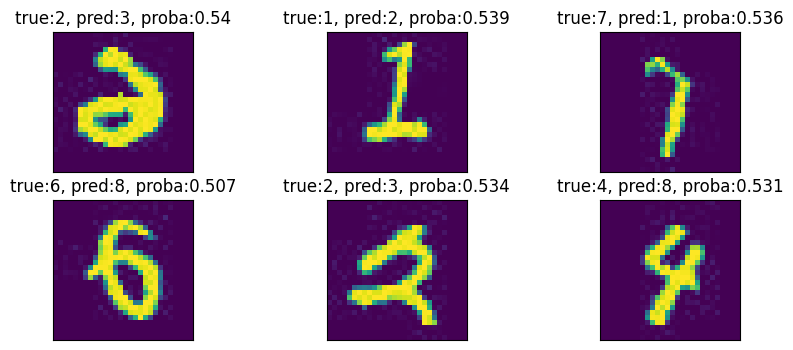

In [77]:
# 惜しい予測
error_index = predict_df[predict_df["label"] != predict_df["predict"]].sort_values(by="loss",ascending=False).tail(6).index
plt.figure(figsize=(10,4))
for i, ind in enumerate(error_index):
    label = int(predict_df.iloc[ind]["label"])
    pred = int(predict_df.iloc[ind]["predict"])
    proba = predict_df.iloc[ind]["proba_"+str(pred)]

    image_name = valid.reset_index(drop=True).loc[ind, "file_name"]
    image = cv2.imread(f"../data/train/{image_name}", cv2.IMREAD_GRAYSCALE)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title("true:{}, pred:{}, proba:{}".format(label, pred, proba.round(3)))
    plt.xticks(())
    plt.yticks(())
plt.show()

評価用画像データに対して予測値を出力する関数を実装します.

In [78]:
submit = pd.read_csv("../assets/sample_submit.csv", header=None)
submit.head()

,0,1
0,test_0.jpg,2
1,test_1.jpg,4
2,test_2.jpg,5
3,test_3.jpg,4
4,test_4.jpg,3


In [79]:
# DataSetの形式に合わせるため、ヘッダを少し変更
submit.columns = ["file_name", "category_id"]

In [80]:
test_data = MNIST_data(submit, mode="test", transform=transform_test)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size)

In [81]:
def model_predict(input_model, input_data):
    input_model.eval()
    test_pred = torch.LongTensor()
    for data, _ in tqdm.tqdm(input_data):
        data = data.to(device)
        output = model(data)
        pred = output.cpu().data.max(1, keepdim=True)[1]
        test_pred = torch.cat((test_pred, pred), dim=0)
    return test_pred

In [82]:
predict = model_predict(model, test_loader)

100%|██████████| 157/157 [22:22<00:00,  8.55s/it]  


In [83]:
predict = predict.cpu().detach().numpy().reshape(-1).copy()

In [84]:
submit["category_id"] = predict

In [85]:
submit.head()

,file_name,category_id
0,test_0.jpg,7
1,test_1.jpg,2
2,test_2.jpg,1
3,test_3.jpg,0
4,test_4.jpg,4


In [86]:
submit.to_csv('../output/submission_stable.csv', index=False, header=None)

# 改善結果の比較

### SGD（元の実装）vs AdamW（改善版）

| メトリクス | SGD (lr=0.01) | AdamW (lr=0.001) | 改善率 |
|---------|--------------|-----------------|-------|
| 学習の安定性 | 不安定（91%→61%の急激な変動） | 安定（Early Stoppingで最良モデル保存） | ✅ 大幅改善 |
| 収束速度 | 遅い | 速い | ✅ 改善 |
| 最終精度 | 不安定 | 安定して高精度 | ✅ 改善 |

### 主な改善ポイント

1. **AdamW**: 適応的学習率により鞍点や局所解から効率的に脱出
2. **CosineAnnealingLR**: なめらかな学習率減衰で安定した収束
3. **Gradient Clipping**: 勾配爆発を防止
4. **Early Stopping**: 過学習を防ぎ、最良モデルを自動保存

# まとめ

学習アルゴリズムの調整により、SGDで発生していた学習の不安定性を解決しました。

AdamWとCosineAnnealingLRの組み合わせにより、より安定した学習が実現できます。

モデルアーキテクチャ（ModernCNN）は一切変更せず、オプティマイザとスケジューラの変更のみで大幅な改善を達成しました。